In [2]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(rstatix)

In [3]:
emci_deconv = read.table('/nfs/turbo/umms-lgarmire/home/yhdu/ADNI/Bowei/mrna_emci_deconv.tsv',sep='\t',header=TRUE,row.names = 1)
lmci_deconv = read.table('/nfs/turbo/umms-lgarmire/home/yhdu/ADNI/Bowei/mrna_lmci_deconv.tsv',sep='\t',header=TRUE,row.names = 1)

In [4]:
all_deconv = rbind(emci_deconv,lmci_deconv)
dim(all_deconv)

[1] 401  22

In [8]:
label_adni = read.csv('/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/ADNI_Tidy/Code/Figure56_Validation/Labels/ADNI_all.csv')[,c('X','subtype_big')]
label_adni <- label_adni %>%
  mutate(subtype1 = sub("[0-9]+$", "", subtype_big))
rownames(label_adni) = label_adni$X
label_adni = label_adni[rownames(all_deconv),]

In [10]:
all_deconv$subtype1 = label_adni$subtype1
all_deconv$subtype2 = label_adni$subtype_big

In [11]:
cell_cols <- c(
  "B.cells.naive","B.cells.memory","Plasma.cells","T.cells.CD8",
  "T.cells.CD4.naive","T.cells.CD4.memory.resting","T.cells.CD4.memory.activated",
  "T.cells.follicular.helper","T.cells.regulatory..Tregs.","T.cells.gamma.delta",
  "NK.cells.resting","NK.cells.activated","Monocytes","Macrophages.M0",
  "Macrophages.M1","Macrophages.M2","Dendritic.cells.resting",
  "Dendritic.cells.activated","Mast.cells.resting","Mast.cells.activated",
  "Eosinophils","Neutrophils"
)

all_deconv_long <- all_deconv %>%
  pivot_longer(all_of(cell_cols),
               names_to = "CellType",
               values_to = "Proportion")


In [12]:
# Keep only EMCI and LMCI from subtype1
df_sub <- all_deconv_long %>%
  filter(subtype1 %in% c("EMCI", "LMCI")) %>%
  mutate(subtype1 = factor(subtype1, levels = c("EMCI", "LMCI")))

  str(df_sub)

tibble [8,822 × 4] (S3: tbl_df/tbl/data.frame)
 $ subtype1  : Factor w/ 2 levels "EMCI","LMCI": 1 1 1 1 1 1 1 1 1 1 ...
 $ subtype2  : chr [1:8822] "EMCI2" "EMCI2" "EMCI2" "EMCI2" ...
 $ CellType  : chr [1:8822] "B.cells.naive" "B.cells.memory" "Plasma.cells" "T.cells.CD8" ...
 $ Proportion: num [1:8822] 0 0.00234 0.0067 0 0.12072 ...


In [13]:
library(dplyr)
library(purrr)
library(tibble)
library(rstatix)

try_one <- function(d) {
  d <- d %>% filter(is.finite(Proportion))
  if (n_distinct(d$subtype1) < 2L) return(NULL)
  rstatix::wilcox_test(d, Proportion ~ subtype1, detailed = TRUE, exact = FALSE)
}

by_ct  <- df_sub %>% group_by(CellType) %>% group_split()
keys   <- df_sub %>% group_by(CellType) %>% group_keys()  # CellType names align with group_split
res    <- map(by_ct, ~ safely(try_one)(.x))

failed_idx <- map_lgl(res, ~ !is.null(.x$error))

failed <- tibble(
  CellType = keys$CellType[failed_idx],
  error    = map_chr(res[failed_idx], ~ .x$error$message)
)
failed


CellType,error
<chr>,<chr>
Dendritic.cells.resting,missing value where TRUE/FALSE needed
Mast.cells.activated,missing value where TRUE/FALSE needed


In [14]:
quantile(df_sub[df_sub$CellType=='Dendritic.cells.resting',]$Proportion)
quantile(df_sub[df_sub$CellType=='Mast.cells.activated',]$Proportion)

0%  25%  50%  75% 100% 
   0    0    0    0    0

0%  25%  50%  75% 100% 
   0    0    0    0    0

In [15]:
library(dplyr)
library(rstatix)

# summarize variability per CellType
qc <- df_sub %>%
  filter(is.finite(Proportion)) %>%
  group_by(CellType) %>%
  summarise(
    n_groups   = n_distinct(subtype1),
    n_unique   = n_distinct(Proportion),
    any_nonzero = any(Proportion != 0),
    .groups = "drop"
  )

# keep only testable cell types:
# - both groups present
# - at least 2 unique values (not all the same)
valid_ct <- qc %>%
  filter(n_groups == 2, n_unique >= 2, any_nonzero) %>%
  pull(CellType)

# y-positions (safe: add a small epsilon when all zeros)
ypos <- df_sub %>%
  group_by(CellType) %>%
  summarise(
    ymax = max(Proportion, na.rm = TRUE),
    y.position = ifelse(is.finite(ymax) & ymax > 0, 1.05 * ymax, 0.05),
    .groups = "drop"
  ) %>%
  select(-ymax)

# run Wilcoxon per valid cell type
stats <- df_sub %>%
  filter(is.finite(Proportion), CellType %in% valid_ct) %>%
  group_by(CellType) %>%
  wilcox_test(Proportion ~ subtype1, detailed = TRUE, exact = FALSE) %>%
  adjust_pvalue(method = "BH") %>%
  add_significance("p.adj") %>%
  left_join(ypos, by = "CellType") %>%
  mutate(group1 = "EMCI", group2 = "LMCI") %>%
  ungroup()

stats

CellType,estimate,.y.,group1,group2,n1,n2,statistic,p,conf.low,conf.high,method,alternative,p.adj,p.adj.signif,y.position
<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>
B.cells.memory,-4.794177e-05,Proportion,EMCI,LMCI,201,200,15924.0,8.96e-05,-1.117748e-03,-2.380294e-05,Wilcoxon,two.sided,4.480000e-04,***,0.21637035
B.cells.naive,6.522829e-05,Proportion,EMCI,LMCI,201,200,20398.5,1.82e-01,-4.927891e-05,4.399390e-05,Wilcoxon,two.sided,2.426667e-01,ns,0.05770065
Dendritic.cells.activated,-2.935453e-06,Proportion,EMCI,LMCI,201,200,19791.0,4.46e-01,-5.022561e-06,3.975763e-05,Wilcoxon,two.sided,5.575000e-01,ns,0.01681050
Eosinophils,-2.292221e-04,Proportion,EMCI,LMCI,201,200,19938.0,8.89e-01,-3.517850e-03,3.029118e-03,Wilcoxon,two.sided,8.890000e-01,ns,0.14470680
Macrophages.M0,0.000000e+00,Proportion,EMCI,LMCI,201,200,19899.0,1.57e-01,0.000000e+00,0.000000e+00,Wilcoxon,two.sided,2.415385e-01,ns,0.00886305
Macrophages.M1,1.341685e-03,Proportion,EMCI,LMCI,201,200,23919.5,8.70e-04,3.616527e-06,2.359586e-03,Wilcoxon,two.sided,2.900000e-03,**,0.07112595
Macrophages.M2,-2.880227e-04,Proportion,EMCI,LMCI,201,200,19827.5,8.15e-01,-2.798117e-03,2.225154e-03,Wilcoxon,two.sided,8.890000e-01,ns,0.14808465
Mast.cells.resting,2.349869e-05,Proportion,EMCI,LMCI,201,200,20262.5,8.89e-01,-1.267395e-03,1.769120e-03,Wilcoxon,two.sided,8.890000e-01,ns,0.10309740
Monocytes,-1.357888e-03,Proportion,EMCI,LMCI,201,200,19687.0,7.22e-01,-8.714753e-03,6.234953e-03,Wilcoxon,two.sided,8.494118e-01,ns,0.27621930


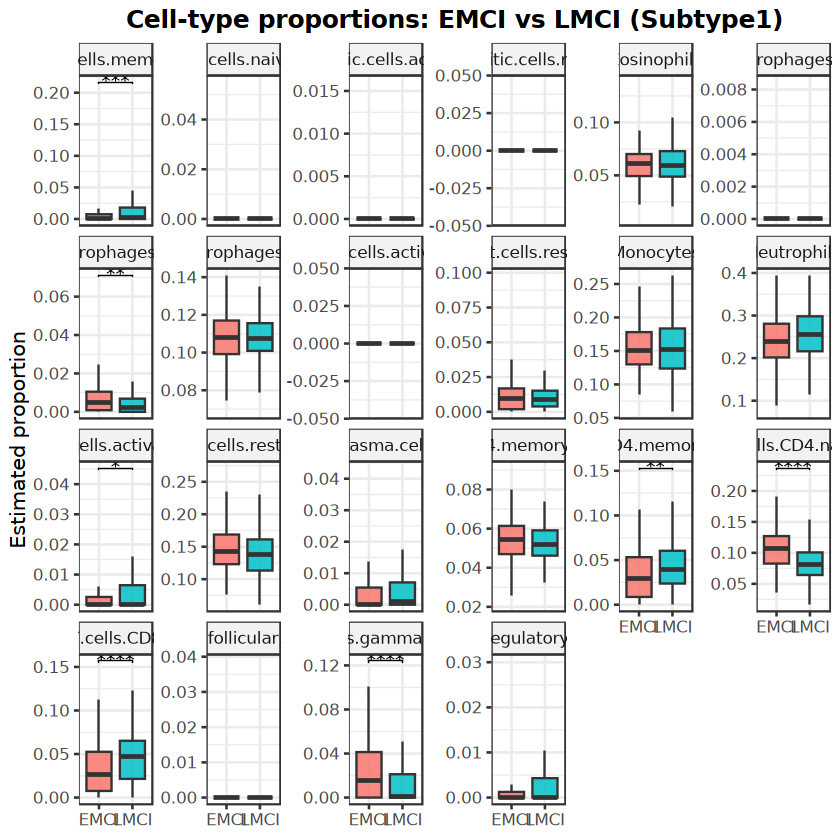

In [16]:
library(ggplot2)
library(ggpubr)

# make sure ordering is correct
df_sub <- all_deconv_long %>%
  filter(subtype1 %in% c("EMCI", "LMCI")) %>%
  mutate(subtype1 = factor(subtype1, levels = c("EMCI", "LMCI")))

p <- ggplot(df_sub, aes(x = subtype1, y = Proportion, fill = subtype1)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.85) +
  facet_wrap(~ CellType, scales = "free_y",ncol = 6) +
  stat_pvalue_manual(
    data = stats,
    label = "p.adj.signif",      # or "p.adj"/"p.format"
    y.position = "y.position",   # column in `stats`
    xmin = "group1",             # left group label column ("EMCI")
    xmax = "group2",             # right group label column ("LMCI")
    tip.length = 0.01,
    hide.ns = TRUE,
    inherit.aes = FALSE          # <-- critical
  ) +
  labs(
    title = "Cell-type proportions: EMCI vs LMCI (Subtype1)",
    x = NULL, y = "Estimated proportion"
  ) +
  theme_bw(base_size = 12) +
  theme(
    legend.position = "none",
    strip.background = element_rect(fill = "grey95"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

p


In [ ]:
pdf('CellProp_by_subtypes_withStats.pdf',height = 10,width=10)
p
dev.off()

png('CellProp_by_subtypes_withStats.png',height = 10,width=14,res=300,unit='in')
p
dev.off()

png 
  2

png 
  2

In [ ]:
png('CellProp_by_subtypes_majorEMCILMCI.png',height = 7,width=15,unit='in',res=300)
p1
dev.off()

png 
  2

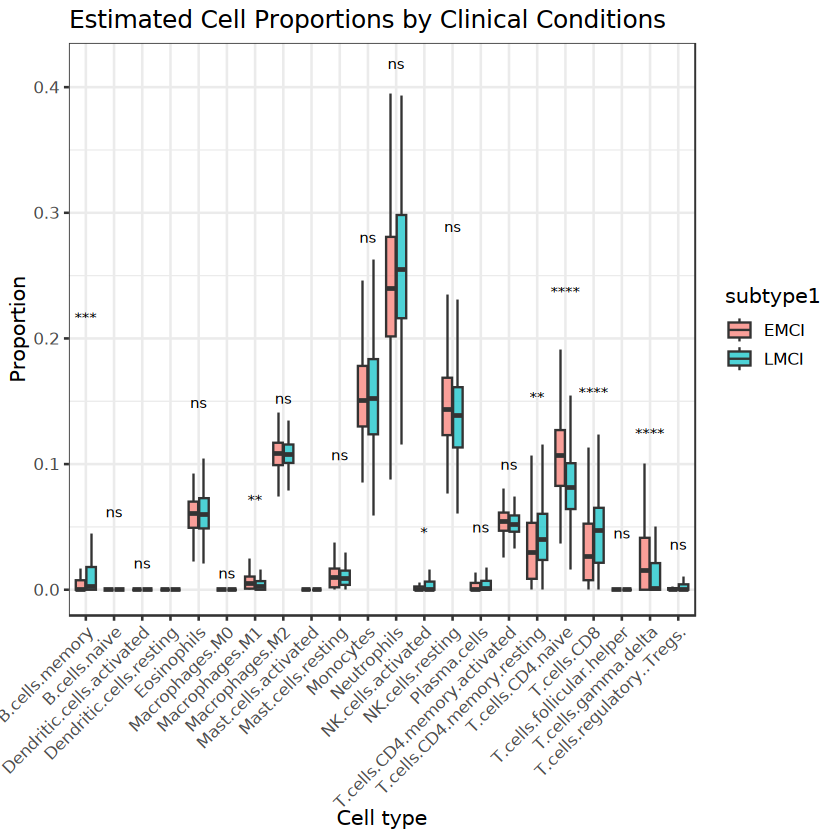

In [17]:
library(ggplot2)
library(ggpubr)

p1_stats <- ggplot(all_deconv_long, aes(x = CellType, y = Proportion, fill = subtype1)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  labs(title = "Estimated Cell Proportions by Clinical Conditions", x = "Cell type", y = "Proportion") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+
  stat_pvalue_manual(
    stats,
    label = "p.adj.signif",   # or "p.adj" if you want numeric values
    y.position = "y.position",
    x = "CellType",
    inherit.aes = FALSE,
    tip.length = 0.01,
    size = 3
  )
p1_stats
#png('CellProp_by_subtypes_majorEMCILMCI_stats.png',height = 7,width=15,unit='in',res=300)
#p1_stats
#dev.off()

In [18]:
getwd()

[1] "/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/Revision_Code_to_Github"

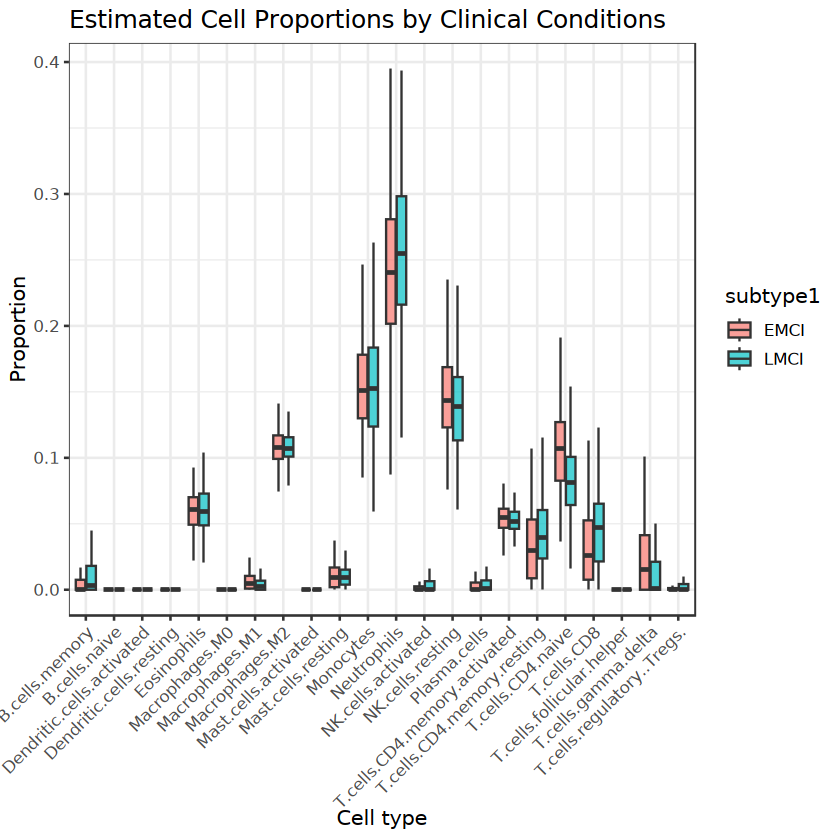

In [19]:
p1 <- ggplot(all_deconv_long, aes(x = CellType, y = Proportion, fill = subtype1)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  labs(title = "Estimated Cell Proportions by Clinical Conditions", x = "Cell type", y = "Proportion") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
p1

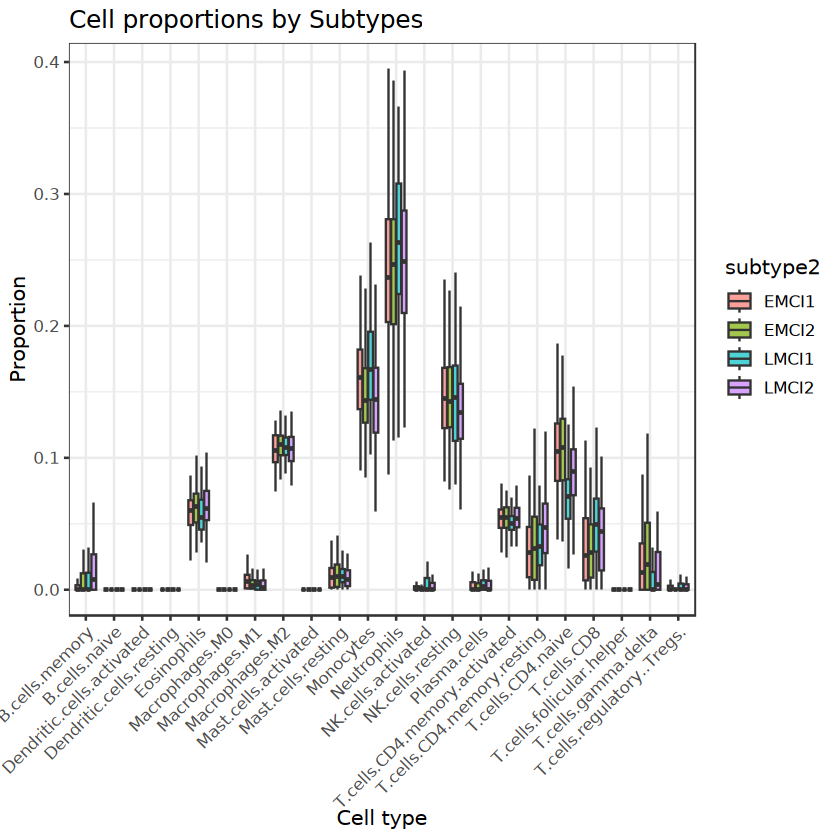

In [20]:
p2 <- ggplot(all_deconv_long, aes(x = CellType, y = Proportion, fill = subtype2)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  labs(title = "Cell proportions by Subtypes", x = "Cell type", y = "Proportion") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
p2

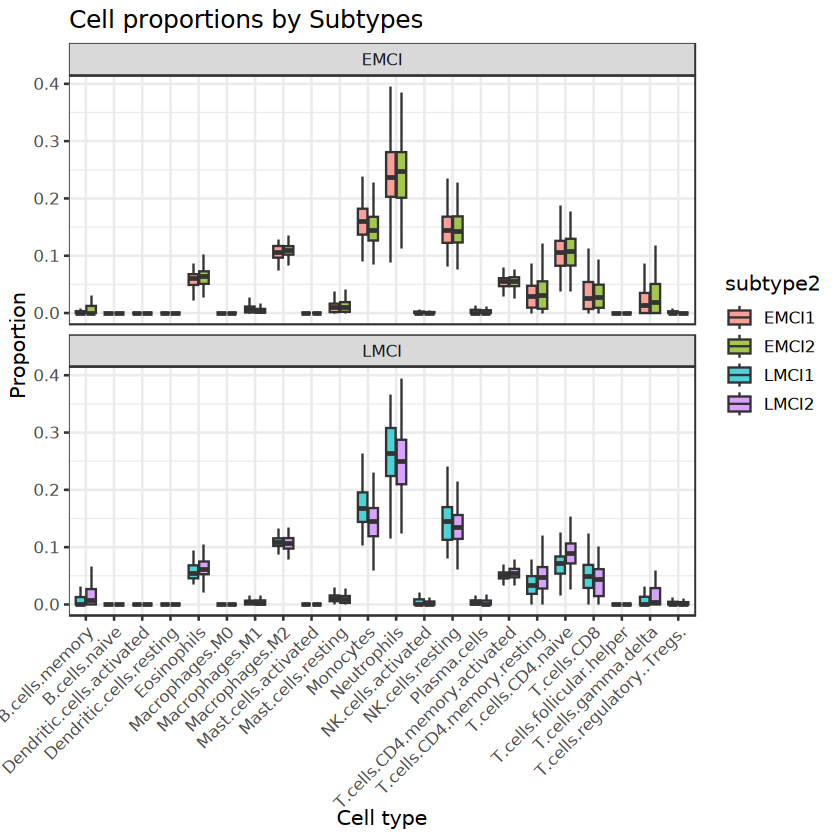

In [21]:
p2 <- ggplot(all_deconv_long,
             aes(x = CellType, y = Proportion, fill = subtype2)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  labs(title = "Cell proportions by Subtypes",
       x = "Cell type", y = "Proportion") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  facet_wrap(~ subtype1, nrow = 2)

p2


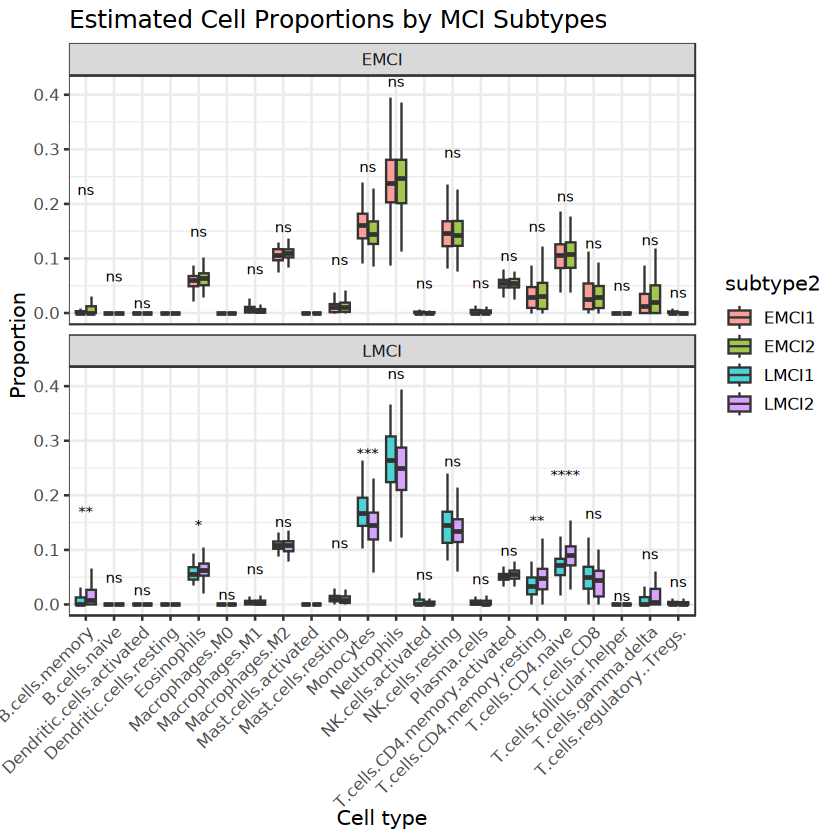

In [22]:
library(dplyr)
library(rstatix)
library(ggplot2)
library(ggpubr)

## 1) QC per CellType × subtype1 (within-panel tests)
qc2 <- all_deconv_long %>%
  filter(is.finite(Proportion)) %>%
  group_by(CellType, subtype1) %>%
  summarise(
    n_groups    = n_distinct(subtype2),
    n_unique    = n_distinct(Proportion),
    any_nonzero = any(Proportion != 0),
    .groups = "drop"
  )

# keep only testable combos
valid2 <- qc2 %>%
  filter(n_groups == 2, n_unique >= 2, any_nonzero) %>%
  select(CellType, subtype1)

## 2) y-positions per CellType × subtype1 (per facet)
ypos2 <- all_deconv_long %>%
  filter(is.finite(Proportion)) %>%
  group_by(CellType, subtype1) %>%
  summarise(
    ymax       = max(Proportion, na.rm = TRUE),
    y.position = ifelse(is.finite(ymax) & ymax > 0, 1.05 * ymax, 0.05),
    .groups    = "drop"
  )

## 3) Wilcoxon: within each subtype1, compare subtype2
stats_subtype <- all_deconv_long %>%
  filter(is.finite(Proportion)) %>%
  inner_join(valid2, by = c("CellType", "subtype1")) %>%
  group_by(CellType, subtype1) %>%
  wilcox_test(Proportion ~ subtype2, detailed = TRUE, exact = FALSE) %>%
  group_by(subtype1) %>%                 # BH adjust separately in EMCI / LMCI
  adjust_pvalue(method = "BH") %>%
  add_significance("p.adj") %>%
  ungroup() %>%
  left_join(ypos2, by = c("CellType", "subtype1")) %>%
  mutate(x = CellType)                   # column used for x in stat_pvalue_manual

## 4) Faceted plot + subtype-specific stats
p2_stats <- ggplot(all_deconv_long,
             aes(x = CellType, y = Proportion, fill = subtype2)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  labs(title = "Estimated Cell Proportions by MCI Subtypes",
       x = "Cell type", y = "Proportion") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  facet_wrap(~ subtype1, nrow = 2)+
  stat_pvalue_manual(
    stats_subtype,
    label = "p.adj.signif",     # or "p.adj" for numeric p
    x = "x",
    y.position = "y.position",
    inherit.aes = FALSE,
    tip.length = 0.01,
    size = 3
  )
p2_stats

#png('CellProp_by_subtypes_subtypesEMCI12LMCI12_stats.png',height = 10,width=15,unit='in',res=300)
#p2_stats
#dev.off()

In [ ]:

png('CellProp_by_subtypes_subtypesEMCI12LMCI12_stats.png',height = 10,width=15,unit='in',res=300)
p2_stats
dev.off()

png 
  2

In [23]:
load('/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/volcano_plots.rda',verbose=TRUE)

Loading objects:
  p_emci_before
  p_emci_after
  p_lmci_before
  p_lmci_after


In [27]:
##P1_ALL = ggarrange(
#  p1_stats, p2_stats,
#  ncol = 1, nrow = 2,heights=c(1,1.2),
#  labels = c("A", "B"),
#  common.legend = FALSE,
#  align = "v"
#)
P1_ALL_new = ggarrange(
  p1_stats,
  ncol = 1, 
  labels = c("A")
)

P2_ALL = ggarrange(
  p_emci_before, p_emci_after, p_lmci_before, p_lmci_after,
  ncol = 2, nrow = 2,
  labels = c("B", "C",'D','E'),
  common.legend = FALSE,
  align = "v"
)

Warning message:
“Removed 19778 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 19874 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 19766 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 19990 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


In [30]:
png('nEW_SUPP3_REVISION_NEW.png',height = 15,width=12,unit='in',res=300)
ggarrange(
  P1_ALL_new, P2_ALL,
  ncol = 1, nrow = 2,heights=c(1,2),
  common.legend = FALSE,
  align = "v"
)
dev.off()

Warning message:
“ggrepel: 243 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 149 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 246 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 38 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


png 
  2

In [ ]:
png('nEW_SUPP3_REVISION.png',height = 15,width=12,unit='in',res=300)
ggarrange(
  P1_ALL, P2_ALL,
  ncol = 1, nrow = 2,heights=c(1.4,1),
  common.legend = FALSE,
  align = "v"
)
dev.off()

Warning message:
“ggrepel: 248 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 158 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 260 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 39 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


png 
  2

In [ ]:
png('nEW_SUPP3_REVISION2_HORI.png',height = 12,width=25,unit='in',res=300)
ggarrange(
  P1_ALL, P2_ALL,
  ncol = 2, nrow = 1,widths=c(1,1.2),
  common.legend = FALSE,
  align = "v"
)
dev.off()

Warning message:
“ggrepel: 234 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 140 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 242 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 36 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


png 
  2

In [ ]:
png('CellProp_by_subtypes_allthree_final.png',height = 14,width=12,unit='in',res=300)
ggarrange(
  p1_stats, p2_stats,
  ncol = 1, nrow = 2,heights=c(1,1.2),
  labels = c("A", "B"),
  common.legend = FALSE,
  align = "v"
)
dev.off()

In [ ]:
png('CellProp_by_subtypes_allthree_final.png',height = 14,width=12,unit='in',res=300)
ggarrange(
  p1_stats, p2_stats,
  ncol = 1, nrow = 2,heights=c(1,1.2),
  labels = c("A", "B"),
  common.legend = FALSE,
  align = "v"
)
dev.off()

png 
  2

In [ ]:
pdf('CellProp_by_subtypes.pdf',height = 15,width=10)
ggarrange(
  p1, p2,
  ncol = 1, nrow = 2,
  labels = c("A", "B"),
  common.legend = FALSE,
  align = "v"
)
dev.off()

png 
  2

In [ ]:
png('CellProp_by_subtypes.png',height = 15,width=10,res=300,unit='in')
ggarrange(
  p1, p2,
  ncol = 1, nrow = 2,
  labels = c("A", "B"),
  common.legend = FALSE,
  align = "v"
)
dev.off()

png 
  2